# Calibration

**This notebook assesses calibration performance of the gradient boosted survival model and recalibrates predictions using isotonic regression for patients with advanced non-small cell lung cancer and high PDL1 receiving first-line pembrolizumab plus chemotherapy or pembrolizumab.**

In [1]:
import sys
sys.path.append('../..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from scipy.stats import linregress
from sklearn.model_selection import StratifiedKFold
from joblib import Parallel, delayed
from sklearn.isotonic import IsotonicRegression
from sksurv.metrics import brier_score

from utils.calibration import calculate_calibration_curve, calibrate_survival_predictions

## Import Data

In [2]:
survival_predictions_df = pd.read_csv('../outputs/gb_survival_predictions.csv')

In [3]:
survival_predictions_df = survival_predictions_df[['PatientID', 'risk_score', 'psurv_180', 'psurv_365']]

In [4]:
survival_predictions_df.shape

(82739, 4)

In [5]:
dtype_map = pd.read_csv('../outputs/pembrochemo_pembro_features_dtypes.csv', index_col = 0).iloc[:, 0].to_dict()
pembro_pembrochemo_df = pd.read_csv('../outputs/pembrochemo_pembro_features_df.csv', dtype = dtype_map)

In [6]:
pembro_pembrochemo_df.shape

(2064, 164)

In [7]:
df = pd.merge(pembro_pembrochemo_df, survival_predictions_df, on = 'PatientID', how = 'left')

In [8]:
df.shape

(2064, 167)

In [9]:
df = df.query('adv_diagnosis_year <= 2023')

In [10]:
df.shape

(1681, 167)

## Raw Calibration Assessment

In [11]:
cal_df = calculate_calibration_curve(df, 'psurv_180', 180)

In [12]:
cal_df

,bin,predicted,observed,n,obs_lo,obs_hi
0,"(0.012799999999999999, 0.525]",0.390359,0.387841,169,0.309442,0.459251
1,"(0.525, 0.641]",0.586734,0.521320,168,0.436352,0.589367
2,"(0.641, 0.701]",0.675034,0.551644,168,0.469609,0.622545
3,"(0.701, 0.742]",0.722578,0.730915,168,0.655875,0.790799
4,"(0.742, 0.776]",0.758761,0.760169,168,0.685315,0.819031
5,"(0.776, 0.804]",0.789410,0.806281,168,0.735889,0.857724
6,"(0.804, 0.827]",0.815539,0.824153,168,0.755757,0.873461
7,"(0.827, 0.851]",0.839205,0.864573,168,0.796677,0.905097
8,"(0.851, 0.879]",0.863824,0.921483,168,0.864106,0.950782
9,"(0.879, 0.94]",0.897439,0.975366,168,0.935677,0.990686


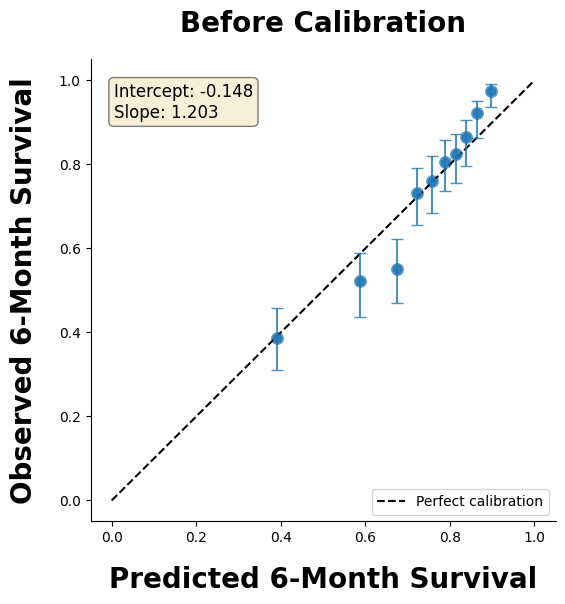

In [13]:
slope_orig, intercept_orig, _, _, _ = linregress(
    cal_df['predicted'], 
    cal_df['observed']
)

# Plot
plt.figure(figsize = (6, 6))
plt.scatter(cal_df['predicted'], cal_df['observed'], s = 70, alpha = 0.6)
plt.plot([0, 1], [0, 1], 'k--', label = 'Perfect calibration')

# Error bar 
yerr = np.vstack([
    cal_df['observed'] - cal_df['obs_lo'],
    cal_df['obs_hi'] - cal_df['observed']
])

plt.errorbar(
    cal_df['predicted'],
    cal_df['observed'],
    yerr = yerr,
    fmt = 'o',           
    elinewidth = 1.5,    
    capsize = 4,         
    alpha = 0.8
)

# Add text box with calibration metrics
textstr = f'Intercept: {intercept_orig:.3f}\nSlope: {slope_orig:.3f}'
plt.text(0.05, 0.95, textstr, transform = plt.gca().transAxes, 
         fontsize = 12, verticalalignment = 'top',
         bbox = dict(boxstyle = 'round', facecolor = 'wheat', alpha = 0.5))

plt.xlabel('Predicted 6-Month Survival', weight = 'bold', labelpad = 15, size = 20)
plt.ylabel('Observed 6-Month Survival', weight = 'bold', labelpad = 15, size = 20)
plt.title('Before Calibration',  weight = 'bold', size = 20, pad = 20)
plt.legend()

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.savefig('../outputs/uncalibrated_gb_6m_survival_prediction_plot.pdf', format = 'pdf', bbox_inches = 'tight')

plt.show()

## Isotonic Calibration Using Cross Validation 

In [14]:
# Prepare structured array for survival outcomes
y_dtype = [('event', bool), ('duration', float)]

y = np.array([tuple(x) for x in df[['event', 'duration']].values],
             dtype = y_dtype)

In [15]:
df, brier_scores = calibrate_survival_predictions(df, y, 'psurv_180', 180)


=== Fold 1/5 ===
Brier score at 180 days (calibrated): 0.1436

=== Fold 2/5 ===
Brier score at 180 days (calibrated): 0.1678

=== Fold 3/5 ===
Brier score at 180 days (calibrated): 0.1555

=== Fold 4/5 ===
Brier score at 180 days (calibrated): 0.1636

=== Fold 5/5 ===
Brier score at 180 days (calibrated): 0.1942

=== Summary ===
psurv_180_calibrated computed: 1681

=== Brier Scores at 180 days (calibrated) ===
Mean: 0.1650 ± 0.0168


In [16]:
df_final_calibrated = df[['PatientID', 'psurv_180_calibrated']]

In [17]:
df_final_calibrated.to_csv('../outputs/gb_6m_survival_predictions_calibrated.csv', index = False)

In [18]:
cal_iso_df = calculate_calibration_curve(df, 'psurv_180_calibrated', 180)

In [19]:
cal_iso_df

,bin,predicted,observed,n,obs_lo,obs_hi
0,"(-0.001, 0.486]",0.376610,0.389278,175,0.312524,0.459280
1,"(0.486, 0.529]",0.512561,0.591092,189,0.510920,0.653519
2,"(0.529, 0.689]",0.601359,0.494672,144,0.406746,0.572876
3,"(0.689, 0.729]",0.716644,0.717846,185,0.646029,0.776327
4,"(0.729, 0.777]",0.764837,0.806834,196,0.741461,0.855884
5,"(0.777, 0.803]",0.792542,0.750974,147,0.671319,0.813078
6,"(0.803, 0.865]",0.852415,0.870133,175,0.808328,0.911701
7,"(0.865, 0.892]",0.881652,0.865654,137,0.789116,0.908890
8,"(0.892, 0.974]",0.926771,0.896528,177,0.837588,0.931328
9,"(0.974, 1.0]",0.987399,0.980252,156,0.940008,0.993590


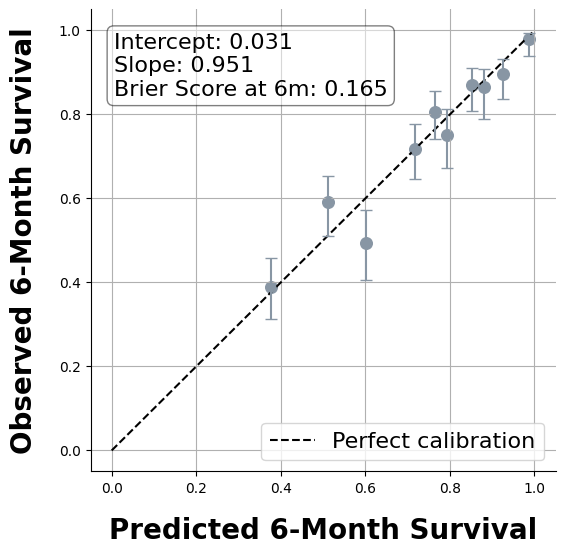

In [20]:
slope_iso, intercept_iso, _, _, _ = linregress(
    cal_iso_df['predicted'], 
    cal_iso_df['observed']
)

# Plot
plt.figure(figsize = (6, 6))
plt.scatter(cal_iso_df['predicted'], cal_iso_df['observed'], s = 70, color='#8896A4')
plt.plot([0, 1], [0, 1], 'k--', label = 'Perfect calibration')

# Error bar 
yerr = np.vstack([
    cal_iso_df['observed'] - cal_iso_df['obs_lo'],
    cal_iso_df['obs_hi'] - cal_iso_df['observed']
])

plt.errorbar(
    cal_iso_df['predicted'],
    cal_iso_df['observed'],
    yerr = yerr,
    fmt = 'o',           
    elinewidth = 1.5,
    color = '#8896A4',
    capsize = 4
)

# Add text box with calibration metrics
textstr = f'Intercept: {intercept_iso:.3f}\nSlope: {slope_iso:.3f}\nBrier Score at 6m: {np.mean(brier_scores):.3f}'
plt.text(0.05, 0.95, textstr, transform = plt.gca().transAxes, 
         fontsize = 16, verticalalignment = 'top',
         bbox = dict(boxstyle = 'round', facecolor = 'white', alpha = 0.5))

plt.xlabel('Predicted 6-Month Survival', weight = 'bold', labelpad = 15, size = 20)
plt.ylabel('Observed 6-Month Survival', weight = 'bold', labelpad = 15, size = 20)
#plt.title('After Isotonic Regression',  weight = 'bold', size = 20, pad = 20)
plt.legend(fontsize=16)
plt.grid(True)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.savefig('../outputs/calibrated_gb_6m_survival_prediction_plot.pdf', format = 'pdf', bbox_inches = 'tight')

plt.show()